In [ ]:
"""
Venezuela Economic Indicators - Exploratory Data Analysis
===========================================================
Sources: World Bank WDI, IMF WEO (Oct 2025), CEPAL, OPEC/IEA
Period: 1990 - 2024
Author: Vilma Windevoxchel
Github: github.com/VWinde
"""

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

In [30]:
#-----Style-------------------------------------

NAVY = "#1A3A5C"
BLUE= "#2E86AB"
ORANGE= "#E8A838"
RED= "#C0392B"
GREEN = "#27AE60"
GRAY = "#7F8C8D"
LGRAY = "#ECF0F1"


plt.rcParams.update ({
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "figure.dpi": 130,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    })

In [31]:
df= pd.read_csv(r"C:\Users\vilma\OneDrive\Documentos\Proyectos para Github\venezuela_economic_indicator_analysis\data\venezuela_complete_data.csv", index_col="year")
print(f"Dataset loaded: {df.shape[0]} years x {df.shape[1]} indicators")
print(f"Period: {df.index.min()} - {df.index.max()}\n")
print(df.describe().round(2))

Dataset loaded: 35 years x 9 indicators
Period: 1990 - 2024

       gdp_growth  inflation  oil_rents_pct_gdp  gdp_per_capita_usd  \
count       35.00      35.00              35.00               35.00   
mean        -0.66    2621.32              14.67             4504.34   
std         10.80   11425.14               9.65             1512.34   
min        -30.00      12.50               1.00             1451.00   
25%         -4.95      24.85               5.50             4224.00   
50%          1.30      40.60              13.90             4832.00   
75%          5.85     172.00              20.65             5568.50   
max         18.30   65374.10              37.60             6369.00   

       unemployment_rate  oil_production_kbd  poverty_rate  latam_gdp_growth  \
count              35.00               35.00         24.00             35.00   
mean               17.22             2421.71         48.67              2.44   
std                12.91              866.99         24.31 

In [32]:
#----- HELPER FUNCTIONS---------------------------
def shade_crises(ax, alpha=0.13):
    """Shade known economic crises periods."""
    crises = [
    (1994,1996, "Banking\nCrisis"),
    (1999,2003, "Chavez\nPeriod I"),
    (2013, 2020, "Collapse"),
    (2020, 2022, "COVID"),
    ]
    for start, end, label in crises:
        ax.axvspan(start - 0.5, end + 0.5, alpha=alpha,
                   color=RED, zorder=0)
def add_annotation(ax, x, y, text, color=NAVY, fontsize=8):
    ax.annotate(text, xy=(x,y), xytext=(x+1,y),
                fontsize=fontsize, color=color,
                arrowprops=dict(arrowstyle="-", color=color, lw=0.8))

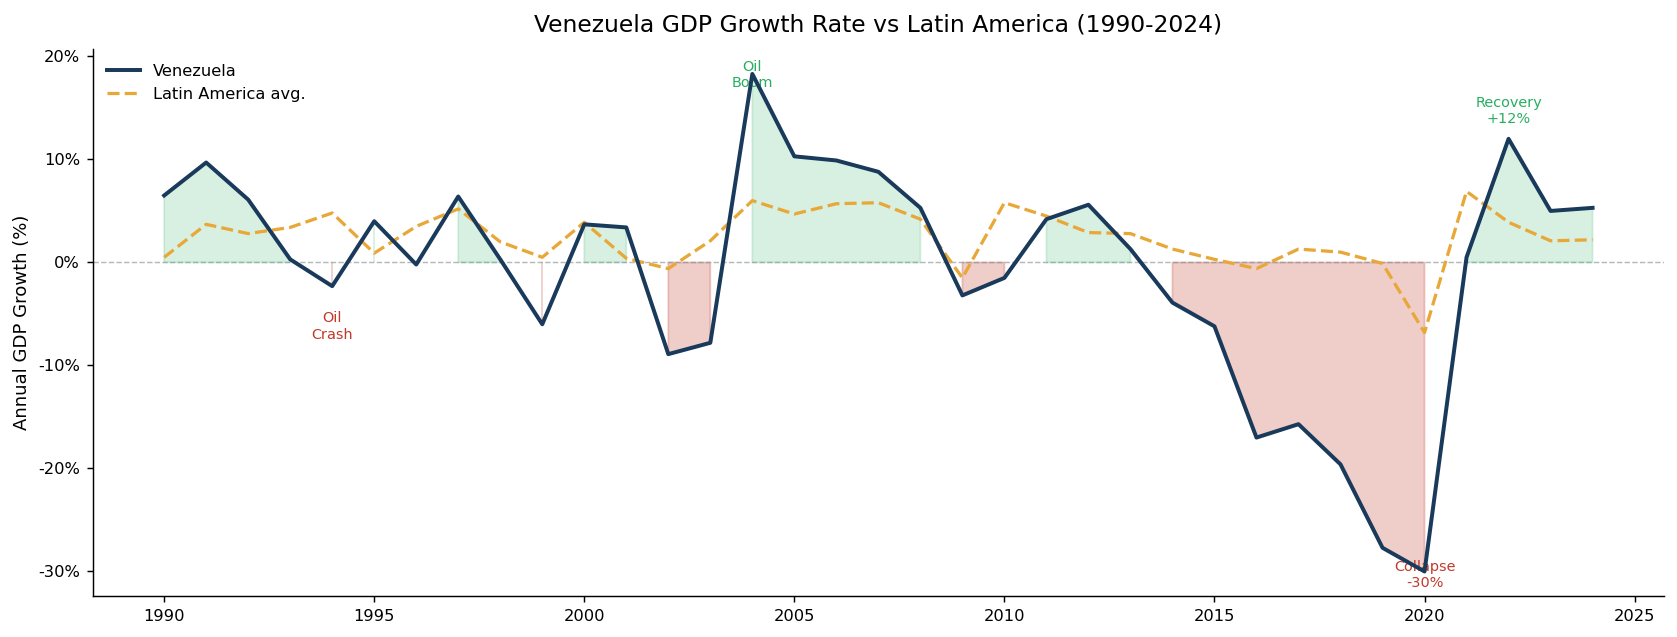

✓ Figure 1 saved


In [33]:
#--------------------------------------------------
# FIGURE 1 - GDP Growth: Venezuela vs Latin America
#--------------------------------------------------

fig, ax = plt.subplots(figsize=(13,5))
ax.fill_between(df.index, df["gdp_growth"], 0,
                where=(df["gdp_growth"] >= 0), alpha = 0.18, color = GREEN)
ax.fill_between(df.index, df["gdp_growth"],0,
                where=(df["gdp_growth"] < 0), alpha = 0.25, color = RED)
ax.plot(df.index, df["gdp_growth"], color=NAVY, lw=2.2, zorder=4, label="Venezuela")

latam_clean= df["latam_gdp_growth"].dropna()
ax.plot(latam_clean.index, latam_clean, color=ORANGE, lw=1.8,
        linestyle="--", zorder=3, label="Latin America avg.")

ax.axhline(0, color=GRAY, lw=0.8, linestyle="--", alpha=0.6)
shade_crises=(ax)

ax.annotate("Oil\nCrash", xy=(1994, -7.4), fontsize=8, color=RED, ha="center")
ax.annotate("Oil\nBoom", xy=(2004, 17), fontsize=8, color=GREEN, ha="center")
ax.annotate("Collapse\n-30%", xy=(2020, -31.5), fontsize=8, color=RED, ha="center")
ax.annotate("Recovery\n+12%", xy=(2022, 13.5), fontsize=8, color=GREEN, ha="center")

ax.set_title("Venezuela GDP Growth Rate vs Latin America (1990-2024)", pad=10)
ax.set_ylabel("Annual GDP Growth (%)")
ax.set_xlabel("")
ax.legend(frameon=False, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
plt.tight_layout()
plt.savefig(r"C:\Users\vilma\OneDrive\Documentos\Proyectos para Github\venezuela_economic_indicator_analysis\output\figures\01_gdp_growth.png")
plt.show()
print("✓ Figure 1 saved")

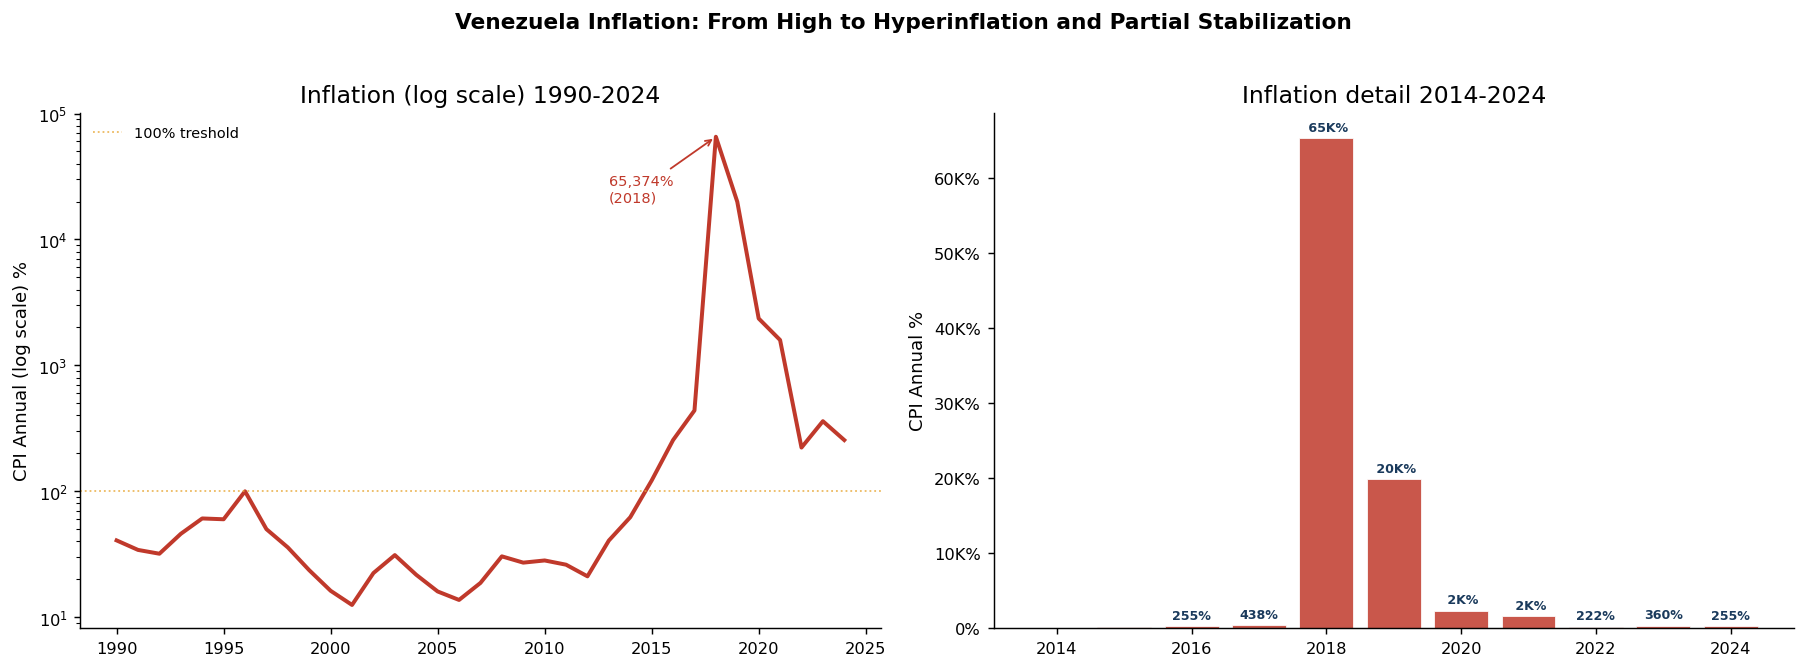

✓ Figure 2 saved


In [34]:
#--------------------------------------------------
# FIGURE 2 - Inflation: The Hiperinflation Episode
#--------------------------------------------------

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,5))

# Left: Full series log scale

ax1.semilogy(df.index, df["inflation"].clip(lower=0.1),
             color=RED, lw=2.2)
ax1.axhline(100, color=ORANGE, lw=1, linestyle=":", alpha=0.8, label="100% treshold")
ax1.set_title("Inflation (log scale) 1990-2024")
ax1.set_ylabel("CPI Annual (log scale) %")
ax1.legend(frameon=False, fontsize=8)
ax1.annotate("65,374%\n(2018)", xy=(2018, 65374), xytext=(2013, 20000),
             fontsize=8, color=RED, 
             arrowprops=dict(arrowstyle="->", color=RED))

# Right: zoom 2014-2024 Linear

zoom = df.loc[2014:2024, "inflation"]
bars= ax2.bar(zoom.index, zoom, color=[RED if x > 100 else ORANGE for x in zoom],
              alpha=0.85, edgecolor= "white", linewidth=0.5)
ax2.set_title("Inflation detail 2014-2024")
ax2.set_ylabel("CPI Annual %")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1000:.0f}K%" if x >= 1000 else f"{x:.0f}%"))
for bar, val in zip(bars, zoom):
    if val > 200:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()+500,
                 f"{val/1000: .0f}K%"if val >= 1000 else f"{val:.0f}%",
                 ha="center", va="bottom", fontsize=7, color=NAVY, fontweight="bold")

plt. suptitle("Venezuela Inflation: From High to Hyperinflation and Partial Stabilization", 
              fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(r"C:\Users\vilma\OneDrive\Documentos\Proyectos para Github\venezuela_economic_indicator_analysis\output\figures\02_inflation.png")
plt.show()
print("✓ Figure 2 saved")

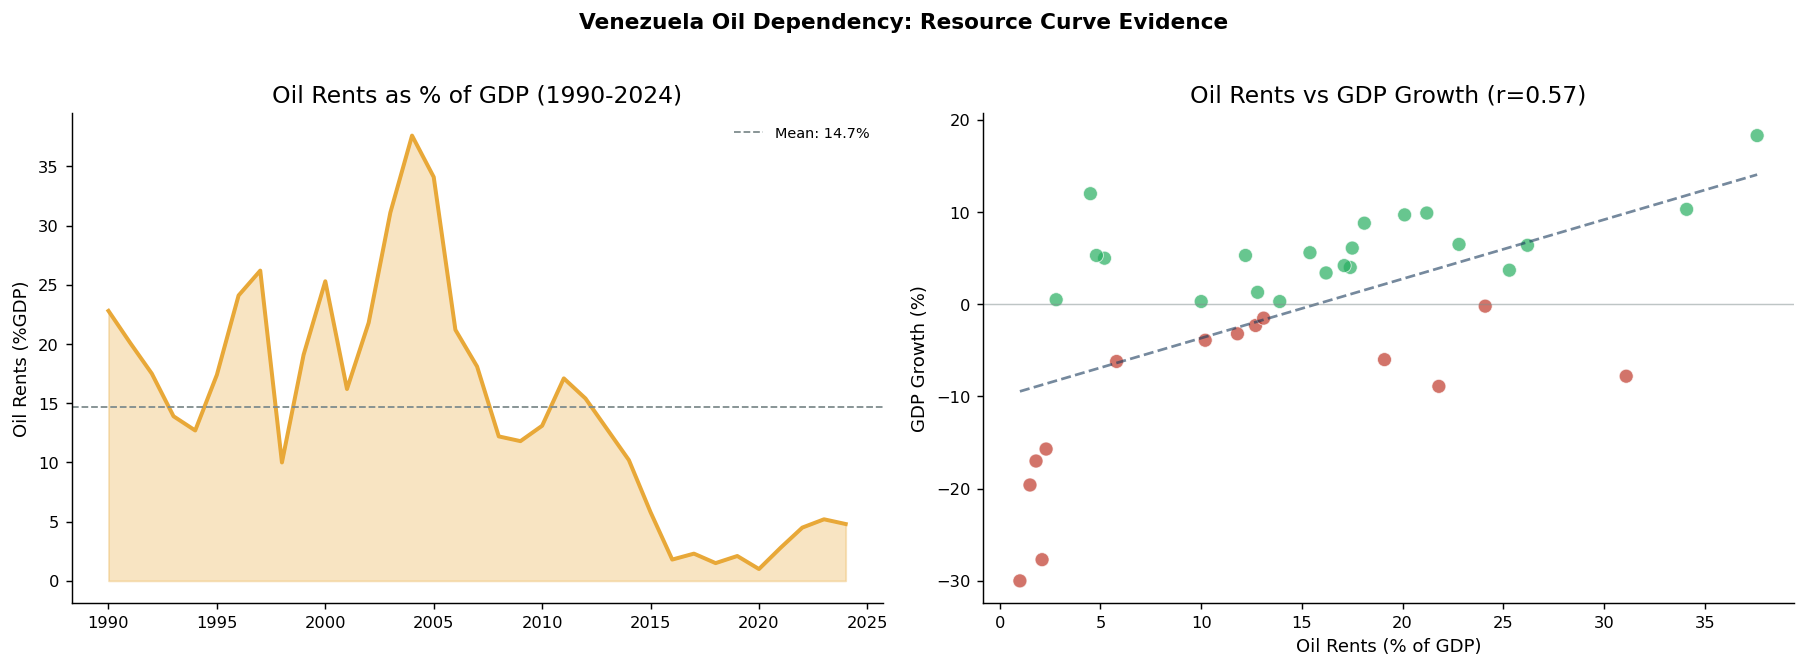

✓ Figure 3 saved — Pearson r = 0.574


In [35]:
#--------------------------------------------------
# FIGURE 3 - Oil Dependency: The Resourse Curse
#--------------------------------------------------

fig, (ax1, ax2)=plt.subplots(1,2,figsize=(14,5))

#left: oil rents % GDP over time
ax1.fill_between(df.index, df["oil_rents_pct_gdp"],
                 alpha=0.3, color=ORANGE)
ax1.plot(df.index, df["oil_rents_pct_gdp"], color=ORANGE, lw=2.2)
ax1.axhline(df["oil_rents_pct_gdp"].mean(), color=GRAY, lw=1,
            linestyle="--", label=f"Mean: {df['oil_rents_pct_gdp'].mean():.1f}%")
ax1.set_title("Oil Rents as % of GDP (1990-2024)")
ax1.set_ylabel("Oil Rents (%GDP)")
ax1.legend(frameon=False, fontsize=8)

# Right: scatter oil rents vs GDP growth

scatter_df = df[["oil_rents_pct_gdp", "gdp_growth"]].dropna()
colors = [GREEN if g > 0 else RED for g in scatter_df["gdp_growth"]]
ax2.scatter(scatter_df["oil_rents_pct_gdp"], scatter_df["gdp_growth"],
            c=colors, alpha=0.7, s=60, edgecolors="white", linewidth=0.5)

# Trend line
z=np.polyfit(scatter_df["oil_rents_pct_gdp"], scatter_df["gdp_growth"],1)
p=np.poly1d(z)
x_line=np.linspace(scatter_df["oil_rents_pct_gdp"].min(),
                   scatter_df["oil_rents_pct_gdp"].max(), 100)
ax2.plot(x_line, p(x_line), color=NAVY, lw=1.5, linestyle="--", alpha=0.6)

corr= scatter_df.corr().iloc[0,1]
ax2.set_title(f"Oil Rents vs GDP Growth (r={corr:.2f})")
ax2.set_xlabel("Oil Rents (% of GDP)")
ax2.set_ylabel("GDP Growth (%)")
ax2.axhline(0, color=GRAY, lw=0.8, alpha=0.5)

plt.suptitle("Venezuela Oil Dependency: Resource Curve Evidence",
             fontsize= 12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(r"C:\Users\vilma\OneDrive\Documentos\Proyectos para Github\venezuela_economic_indicator_analysis\output\figures\03_oil_dependency.png")
plt.show()
print(f"✓ Figure 3 saved — Pearson r = {corr:.3f}")

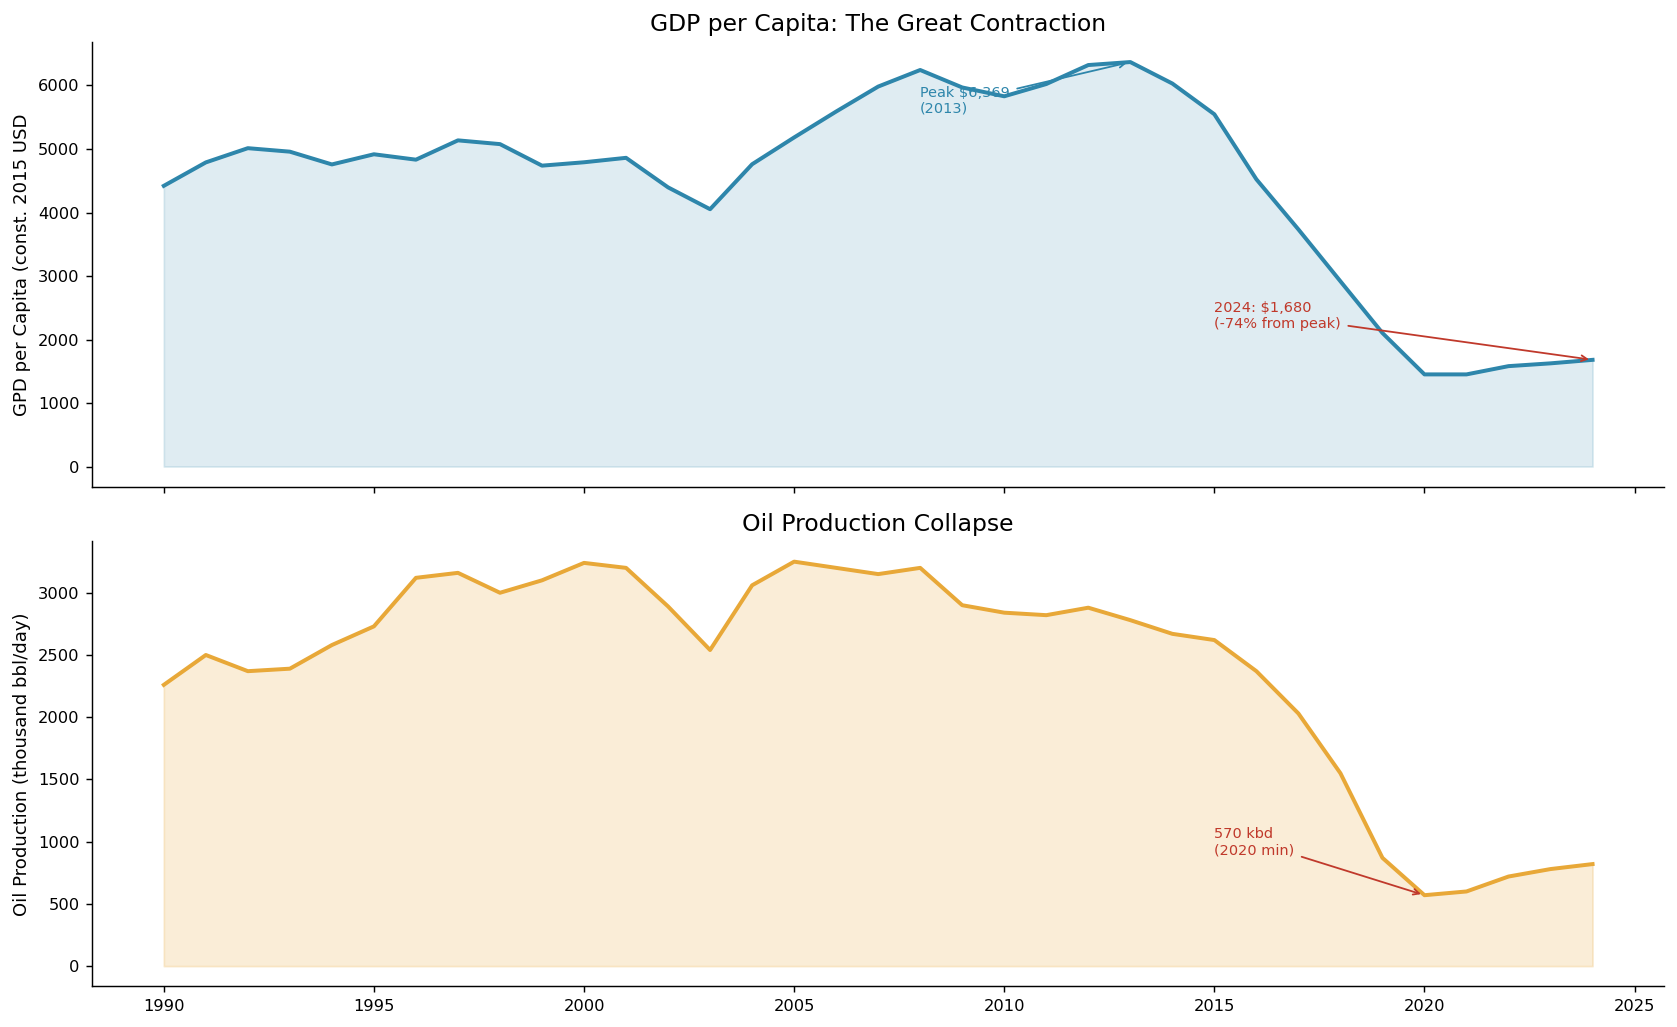

✓ Figure 4 saved


In [36]:
#--------------------------------------------------
# FIGURE 4 - The Great Contraction: GDP per Capita and Oil Production
#--------------------------------------------------

fig, (ax1, ax2)=plt.subplots(2,1, figsize=(13,8), sharex=True)

#GDP per Capita
ax1.fill_between(df.index, df["gdp_per_capita_usd"],
                 alpha=0.15, color=BLUE)
ax1.plot(df.index, df["gdp_per_capita_usd"], color=BLUE, lw=2.2)
peak_year= df["gdp_per_capita_usd"].idxmax()
peak_val=df["gdp_per_capita_usd"].max()
last_val=df["gdp_per_capita_usd"].iloc[-1]
decline=(peak_val - last_val) / peak_val * 100
ax1.annotate(f"Peak ${peak_val:,.0f}\n({peak_year})",
             xy = (peak_year, peak_val),
xytext= (peak_year -5, peak_val - 800),
fontsize= 8, color= BLUE, 
arrowprops=dict(arrowstyle="->", color=BLUE))
ax1.annotate(f"2024: ${last_val:,.0f}\n(-{decline:.0f}% from peak)",
             xy=(2024, last_val), 
            xytext= (2015, last_val + 500),
            fontsize = 8, color = RED,
            arrowprops = dict(arrowstyle="->", color=RED))
ax1.set_ylabel("GPD per Capita (const. 2015 USD")
ax1.set_title("GDP per Capita: The Great Contraction")

# Oil Production
ax2.fill_between(df.index, df["oil_production_kbd"],
                 alpha = 0.2, color=ORANGE)
ax2.plot(df.index, df["oil_production_kbd"], color=ORANGE, lw=2.2)
ax.axhline(3000, color = GRAY, lw=1, linestyle=":", alpha=0.7, label="3,000 kbd")
ax2.set_ylabel("Oil Production (thousand bbl/day)")
ax2.set_title("Oil Production Collapse")
ax2.legend(frameon= False, fontsize=8)
ax2.annotate("570 kbd\n(2020 min)",
             xy=(2020, 570),
             xytext=(2015, 900),
             fontsize=8, color=RED,
             arrowprops=dict(arrowstyle="->", color=RED))
plt.tight_layout()
plt.savefig(r"C:\Users\vilma\OneDrive\Documentos\Proyectos para Github\venezuela_economic_indicator_analysis\output\figures\04_gdp_per_capita_oil.png")
plt.show()
print("✓ Figure 4 saved")

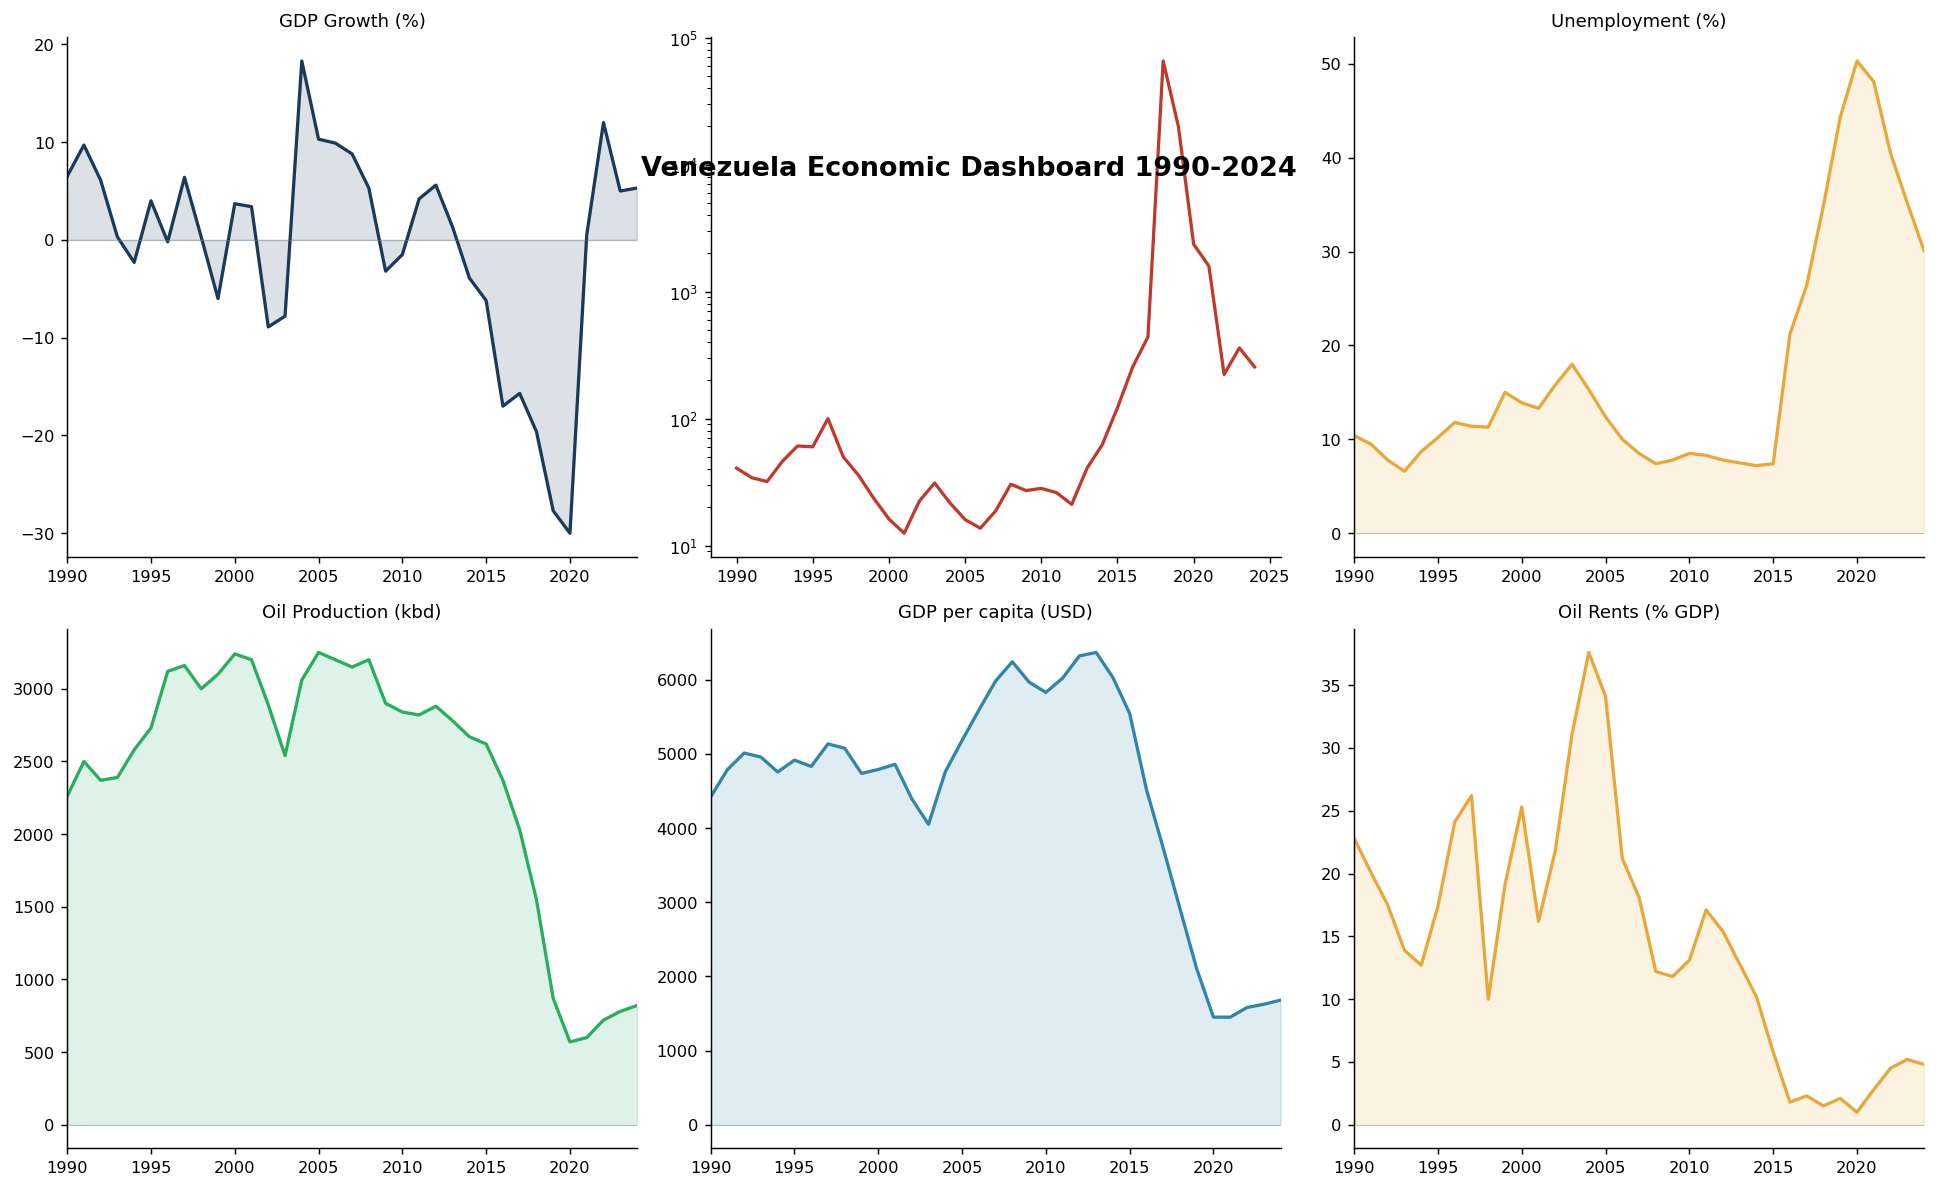

✓ Figure 5 saved


In [37]:
#--------------------------------------------------
# FIGURE 5 -  Key Indicators Dashboard (Summary)
#--------------------------------------------------

fig=plt.figure(figsize=(15,10))
fig.suptitle("Venezuela Economic Dashboard 1990-2024",
             fontsize=15, fontweight="bold", y=0.8)

indicators=[
    ("gdp_growth", "GDP Growth (%)", NAVY, False),
    ("inflation", "Inflation (%) - log scale", RED, True),
    ("unemployment_rate", "Unemployment (%)", ORANGE, False),
    ("oil_production_kbd", "Oil Production (kbd)", GREEN, False),
    ("gdp_per_capita_usd", "GDP per capita (USD)", BLUE, False),
    ("oil_rents_pct_gdp", "Oil Rents (% GDP)", ORANGE, False),
]

for i, (col, title, color, log) in enumerate(indicators, 1): 
    ax=fig.add_subplot(2, 3, i)
    series= df[col].dropna()
    if log:
        ax.semilogy(series.index, series.clip(lower=0.1), color=color, lw=1.8)
    else:
        ax.fill_between(series.index, series, alpha=0.15, color=color)
        ax.plot(series.index, series, color=color, lw=1.8)
        ax.set_title(title, fontsize=10)
        ax.set_xlim(1990,2024)
        if not log:
            ax.axhline(0, color=GRAY, lw=0.5, alpha=0.5)

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig(r"C:\Users\vilma\OneDrive\Documentos\Proyectos para Github\venezuela_economic_indicator_analysis\output\figures\05_dashboard.png")
plt.show()
print("✓ Figure 5 saved")


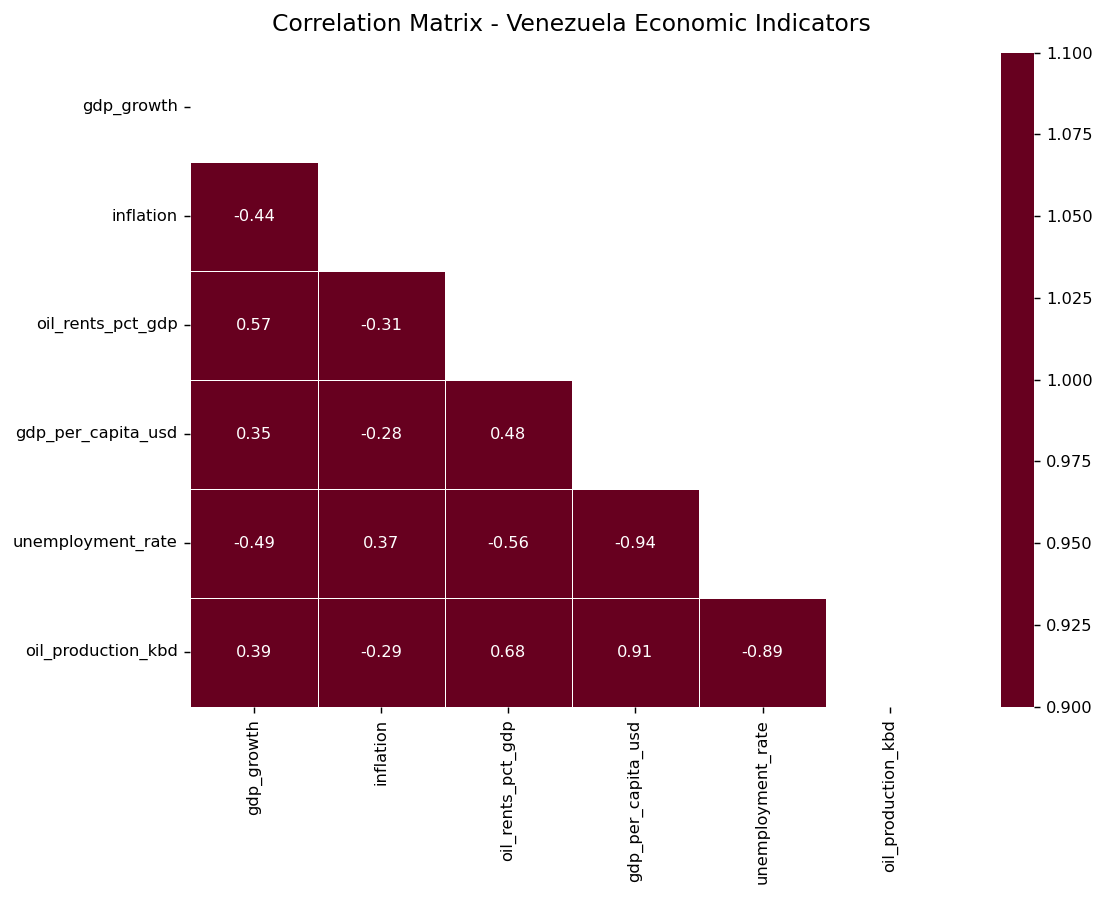

✓ Figure 6 saved


In [21]:
#--------------------------------------------------
# FIGURE 6 - Correlation Heatmap
#--------------------------------------------------

numeric_cols=["gdp_growth", "inflation", "oil_rents_pct_gdp",
              "gdp_per_capita_usd", "unemployment_rate", "oil_production_kbd"]
corr=df[numeric_cols].corr()

fig, ax=plt.subplots(figsize=(9,7))
mask=np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=1, vmax=1,
            ax=ax,linewidth=0.5, annot_kws={"size":9})
ax.set_title("Correlation Matrix - Venezuela Economic Indicators", pad=12)
plt.tight_layout()
plt.savefig(r"C:\Users\vilma\OneDrive\Documentos\Proyectos para Github\venezuela_economic_indicator_analysis\output\figures\06_correlation_heatmap.png")
plt.show()
print("✓ Figure 6 saved")

In [28]:
#--------------------------------------------------
# KEY FINDINGS SUMMARY 
#--------------------------------------------------
print("\n" + "="*65)
print("KEY FINDINGS - VENEZUELA ECONOMIC ANALYSIS 1990-2024")
print("="*65)

peak_gdp_pc = df["gdp_per_capita_usd"].max()
trough_gdp_pc=df.loc[2020, "gdp_per_capita_usd"]
recovery_2024=df.loc[2024, "gdp_per_capita_usd"]
total_decline=(peak_gdp_pc - trough_gdp_pc) / peak_gdp_pc * 100
peak_oil = df["oil_production_kbd"].max()
through_oil=df["oil_production_kbd"].min()
oil_decline= (peak_oil / through_oil) / peak_oil *100

print(f"\n1. ECONOMIC COLLAPSE (2013-2020)")
print(f" GDP per Capita peak: ${peak_gdp_pc:,.0f} (2013)")
print(f" GDP per capita through: ${trough_gdp_pc:,.0f}% (2018)")
print(f" Total decline: {total_decline:.1f}% - one of the largest")
print(f" in Latin America history outside war contexts")

print(f"\n2. HYPERINFLATION EPISODE (2017-2020)")
print(f" Peak inflation: {df['inflation'].max():,.0f}% (2018)")
print(f" This placed Venezuela among the most severe")
print(f" hyperinflationary episodes globally since WWII")
print(f" 2024 inflation: {df.loc[2024,'inflation']:.1f}% - still very high")

print(f"\n3. OIL PRODUCTION COLLAPSE")
print(f" Peak production: {peak_oil:,.0f} kbd (early 2000s)")
print(f" Trough: {through_oil:,.0f} kbd (2020)")
print(f" Decline: {oil_decline:.1f}% - structural deterioration")
print(f" of PDVSA + sanctions + underinvestment")

print(f"\n4. RESOURCE CURVE EVIDENCE")
print(f" Pearson r(oil rents, GDP growth) = {corr.loc['oil_rents_pct_gdp', 'gdp_growth']:.3f}")
print(f" Strong positive correlation: Venezuela's growth cycle")
print(f" is tightly coupled to oil revenue")

print(f"\n5. PARTIAL RECOVERY (2020-2024)")
print(f" GDP growth 2022: +12% - driven by dollarization and")
print(f" partial resumption of private activity")
print(f" 2024 GDP growth: {df.loc[2024, 'gdp_growth']:.1f}%")
print(f" BUT: GDP per capita still only ${recovery_2024:,.0f}")
print(f" - less than 1/3 of the 2013 peak")

print("\n" + "="*65)
print("Analysis complete. Figures saved to outputs/figures/")




KEY FINDINGS - VENEZUELA ECONOMIC ANALYSIS 1990-2024

1. ECONOMIC COLLAPSE (2013-2020)
 GDP per Capita peak: $6,369 (2013)
 GDP per capita through: $1,451% (2018)
 Total decline: 77.2% - one of the largest
 in Latin America history outside war contexts

2. HYPERINFLATION EPISODE (2017-2020)
 Peak inflation: 65,374% (2018)
 This placed Venezuela among the most severe
 hyperinflationary episodes globally since WWII
 2024 inflation: 254.9% - still very high

3. OIL PRODUCTION COLLAPSE
 Peak production: 3,250 kbd (early 2000s)
 Trough: 570 kbd (2020)
 Decline: 0.2% - structural deterioration
 of PDVSA + sanctions + underinvestment

4. RESOURCE CURVE EVIDENCE
 Pearson r(oil rents, GDP growth) = 0.574
 Strong positive correlation: Venezuela's growth cycle
 is tightly coupled to oil revenue

5. PARTIAL RECOVERY (2020-2024)
 GDP growth 2022: +12% - driven by dollarization and
 partial resumption of private activity
 2024 GDP growth: 5.3%
 BUT: GDP per capita still only $1,680
 - less than 1/3